## Run in colab , vscode have some issues

### Importing of Libraries

In [2]:
# ------------------------------------------------------------
# 1️⃣  Imports & environment
# ------------------------------------------------------------
from __future__ import annotations

import operator
from pathlib import Path
from typing import List, TypedDict, Annotated

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

load_dotenv()          # <-- reads .env for GROQ_API_KEY

True

In [3]:
# ------------------------------------------------------------
# 2️⃣  LLM (shared by all nodes)
# ------------------------------------------------------------
# You can swap this for any other LangChain‑compatible LLM.
llm = ChatGroq(model="openai/gpt-oss-120b")   # 120‑billion‑parameter model


### Pydantic Schema

In [4]:
# ------------------------------------------------------------
# 3️⃣  Data models
# ------------------------------------------------------------
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover in this section")

class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

### State Graph

In [5]:
# ------------------------------------------------------------
# 4️⃣  Graph state definition
# ------------------------------------------------------------
class State(TypedDict):
    """All keys that travel through the graph."""
    topic: str                     # user input
    plan: Plan                     # created by orchestrator
    sections: Annotated[List[str], operator.add]   # result from worker node concated 
    final: str                     # final markdown (saved to disk)

### Nodes

In [6]:
# ------------------------------------------------------------
# 5️⃣  Node implementations
# ------------------------------------------------------------
def orchestrator(state: State) -> dict:
    """
    Calls the LLM once to get a full blog plan (title + 5‑7 sections).
    """
    # we are forcing our llm to be always Plan object we defined above
    plan: Plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content="Create a blog plan with 5‑7 sections on the following topic."
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    # Return the new piece of state – everything else is unchanged.
    return {"plan": plan}

In [12]:
orchestrator({"topic":"Jain"})['plan']

Plan(blog_title='Exploring Jainism: History, Philosophy, and Modern Relevance', tasks=[Task(id=1, title='Introduction to Jainism', brief='Provide an overview of Jainism, its origins, and its significance as one of the oldest Indian religions.'), Task(id=2, title='Historical Development', brief='Trace the evolution of Jainism from the time of the 24 Tirthankaras, focusing on key figures like Mahavira and the spread of Jain communities.'), Task(id=3, title='Core Beliefs and Philosophy', brief='Explain the fundamental doctrines such as Ahimsa (non‑violence), Anekantavada (many‑sidedness), and Aparigraha (non‑possessiveness), and how they shape Jain ethics.'), Task(id=4, title='Practices and Rituals', brief='Describe daily practices, dietary restrictions, pilgrimage sites, festivals (e.g., Paryushana, Mahavir Jayanti), and the role of monks and nuns.'), Task(id=5, title='Jain Art, Architecture, and Literature', brief='Highlight iconic temples, sculptures, manuscripts, and contributions to 

fanout is a LangGraph node that splits a high‑level plan into many independent Send messages, each of which triggers a "worker" node to run in parallel.

In [13]:

def fanout(state: State) -> list[Send]:
    """
    Turn each Task into a separate worker payload.
    """
    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"],
            },
        )
        for task in state["plan"].tasks
    ]

In [38]:
def worker(payload: dict) -> dict:
    """
    One worker receives a single Task and writes the markdown for that section.
    """
    task: Task = payload["task"]
    topic: str = payload["topic"]
    plan: Plan = payload["plan"]

    section_md: str = llm.invoke(
        [
            SystemMessage(content="Write ONE clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Overall topic: {topic}\n\n"
                    f"Section title: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return ONLY the markdown for the section (no extra text)."
                )
            ),
        ]
    ).content.strip()

    # The reducer expects a key called `sections`.  Because the state field
    # is declared as `Annotated[List[str], operator.add]`, LangGraph will
    # automatically concatenate the lists from every worker.
    return {"sections": [section_md]}

In [39]:
def reducer(state: State) -> dict:
    """
    Assemble the final markdown, write it to a file, and expose it as `final`.
    """
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- Save to a markdown file (optional) ----
    filename = title.lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")
    print(f"✅  Written {filename}")

    return {"final": final_md}

### Graph

In [40]:
# ------------------------------------------------------------
# 6️⃣  Build the graph
# ------------------------------------------------------------
g = StateGraph(State)

g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

# Linear flow: START → orchestrator
g.add_edge(START, "orchestrator")

# After orchestrator we *branch* to as many workers as there are tasks.
g.add_conditional_edges("orchestrator", fanout, ["worker"])

# Every worker feeds into the reducer (LangGraph will automatically merge the
# `sections` list because of the `Annotated[..., operator.add]` declaration).
g.add_edge("worker", "reducer")

# End of the workflow
g.add_edge("reducer", END)

app = g.compile()

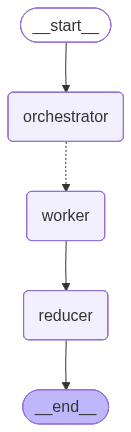

In [41]:
app

In [42]:
out = app.invoke({"topic": "Write a blog on GENAI"})

✅  Written genai:_transforming_the_future_of_content_creation_and_ai.md


In [43]:
inp = {"topic": "Write a blog on GENAI"}
result = app.invoke(inp)
# `result` contains the whole final state.
print("\n=== FINAL MARKDOWN ===\n")
print(result["final"])

✅  Written demystifying_generative_ai:_from_basics_to_real‑world_impact.md

=== FINAL MARKDOWN ===

# Demystifying Generative AI: From Basics to Real‑World Impact

## Introduction – What is Generative AI?

Generative AI refers to a class of machine‑learning models that can **create new content**—text, images, audio, code, or even video—by learning the underlying patterns of existing data. Unlike traditional AI systems that excel at classification, prediction, or decision‑making based on predefined rules, generative models **produce** novel outputs that were never explicitly seen during training.

### How it differs from traditional AI

| Traditional AI | Generative AI |
|----------------|---------------|
| **Goal:** Identify or predict labels (e.g., spam vs. not‑spam) | **Goal:** Synthesize new data (e.g., write a poem, design a logo) |
| **Typical models:** Decision trees, logistic regression, discriminative neural nets | **Typical models:** Variational autoencoders, GANs, diffusion m